<a href="https://colab.research.google.com/github/zain4cs/Feature-Engineering/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Feature Engineering:**

```
* Feature Engineering & Types
```



# Feature Transformation:

1.   Missing Value's
2.   Handling Categorical


1.   Outlier Detection
2.   Feature Scaling






> # Feature Construction:
     This is about creating new features from your existing data using logic or domain knowledge.
     You combine two or more columns to make a new one that might be more useful


> # Feature Selection:
This is about picking the best features

> # Feature Extraction:
This is about transforming the data





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/Social_Network_Ads.csv")

In [3]:
df  = df.iloc[:,2:]

In [4]:
df.sample(5)

,Age,EstimatedSalary,Purchased
240,42,149000,1
106,26,35000,0
365,59,29000,1
291,49,89000,1
107,27,89000,0


___________________

**Import  (ML)  Library**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
x = df.drop("Purchased", axis=1)
y = df["Purchased"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [7]:
x_train.shape, x_test.shape

((280, 2), (120, 2))

In [8]:
scaler = StandardScaler()
scaler.fit(x_train)

x_train_scale = scaler.transform(x_train)
x_test_scale = scaler.transform(x_test)

In [9]:
scaler.mean_

array([3.75750000e+01, 7.05892857e+04])

In [10]:
x_train_scale = pd.DataFrame(x_train_scale, columns=x_train.columns)
x_test_scale = pd.DataFrame(x_test_scale, columns=x_test.columns)

In [11]:
x_test_scale.head()

,Age,EstimatedSalary
0,0.827784,-1.433827
1,2.105076,0.513775
2,-0.940775,-0.784626
3,1.024290,0.749848
4,-0.842522,-1.256772


___________

**Comparison**

In [12]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.6,70589.3
std,10.2,33948.5
min,18.0,15000.0
25%,30.0,44000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [13]:
np.round(x_train_scale.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


________________

**Graph**

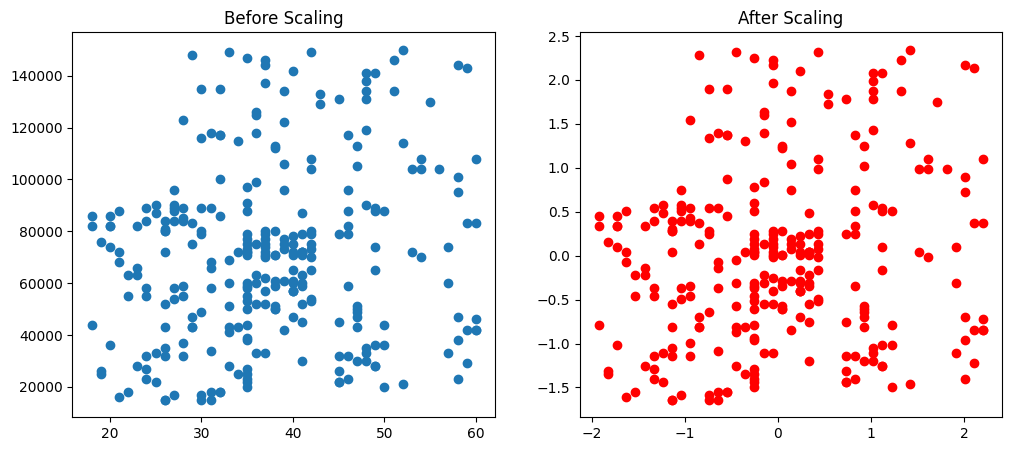

In [14]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x_train["Age"], x_train["EstimatedSalary"])
ax1.set_title("Before Scaling")


ax2.scatter(x_train_scale["Age"], x_train_scale["EstimatedSalary"], color='red')
ax2.set_title("After Scaling")

plt.show()

__________________________

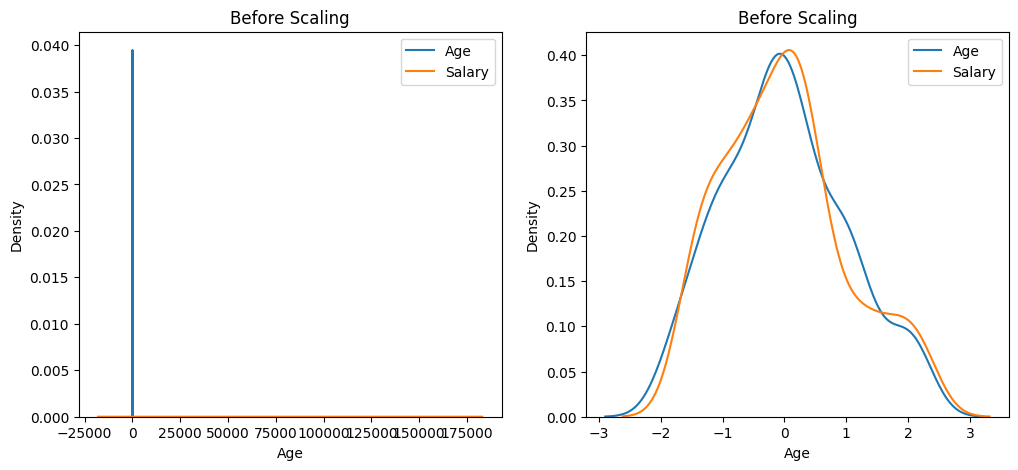

In [15]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Age'],ax=ax1, label='Age')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1, label='Salary')
ax1.legend()


# After Scaling
ax2.set_title("Before Scaling")
sns.kdeplot(x_train_scale['Age'],ax=ax2, label='Age')
sns.kdeplot(x_train_scale['EstimatedSalary'], ax=ax2, label='Salary')
ax2.legend()
# plt.tight_layout()


<Axes: title={'center': 'After Scaling Distribution'}, xlabel='Age', ylabel='Density'>

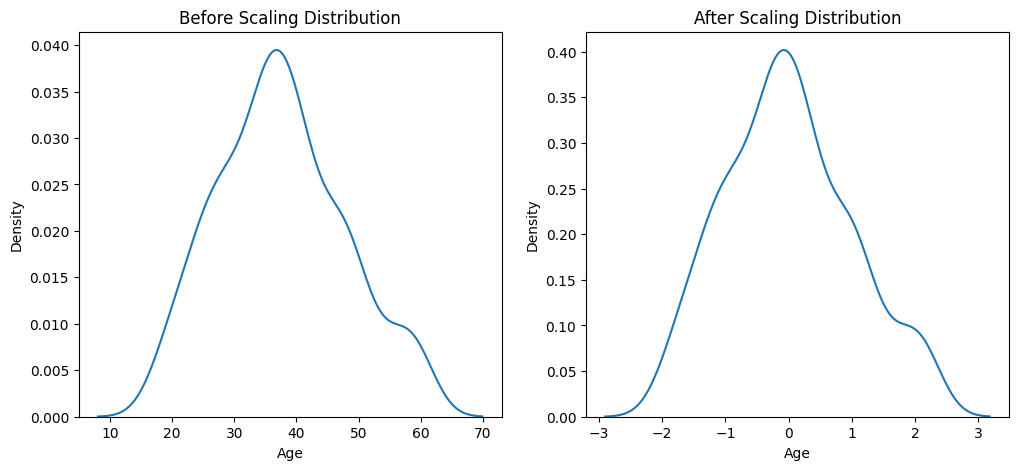

In [16]:
fig, (pl1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

pl1.set_title("Before Scaling Distribution")
sns.kdeplot(x_train['Age'], ax=pl1)

ax2.set_title("After Scaling Distribution")
sns.kdeplot(x_train_scale['Age'], ax=ax2)

____________________________________

**Apply ML Model**

**Why scaling is important**

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [19]:
lr.fit(x_train, y_train)
lr_scaled.fit(x_train_scale, y_train)

LogisticRegression()

In [20]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scale)

**Now check Accuracy**

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
print("Actual Accuracy", accuracy_score(y_test, y_pred))
print("Scaled Accuracy", accuracy_score(y_test, y_pred_scaled))

Actual Accuracy 0.85
Scaled Accuracy 0.85


**Apply Dscision Tree**

In [23]:
from sklearn.tree import DecisionTreeClassifier

In [24]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [25]:
dt.fit(x_train, y_train)
dt_scaled.fit(x_train_scale, y_train)

DecisionTreeClassifier()

In [26]:
y_pred = dt.predict(x_test)
y_pred_scaled = dt_scaled.predict(x_test_scale)

In [27]:
print("Actual Accuracy", accuracy_score(y_test, y_pred))
print("Scaled Accuracy", accuracy_score(y_test, y_pred_scaled))

Actual Accuracy 0.8666666666666667
Scaled Accuracy 0.8416666666666667


_____________________

**Effect Of Outliers**

In [32]:
new_data = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})

df = pd.concat([df, new_data], ignore_index=True)

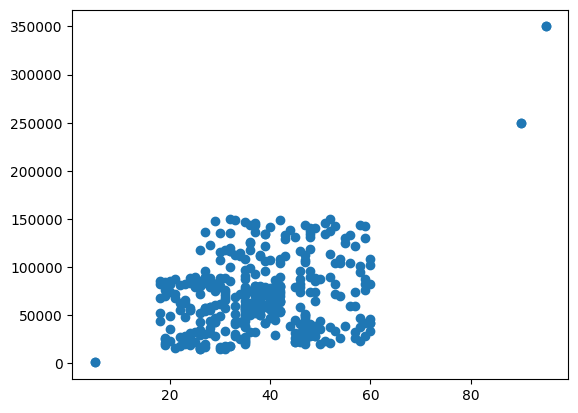

In [40]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [36]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=True), df['Purchased'], test_size=0.3, random_state=42)
x_train.shape, x_test.shape

((284, 2), (122, 2))

In [39]:
df_scale = StandardScaler()
df_scale.fit(x_train)

x_train_scale = df_scale.transform(x_train)
x_test_scale = df_scale.transform(x_test)

In [46]:
X_train_scale = pd.DataFrame(x_train_scale, columns=x_train.columns)
X_test_scale = pd.DataFrame(x_test_scale, columns=x_test.columns)

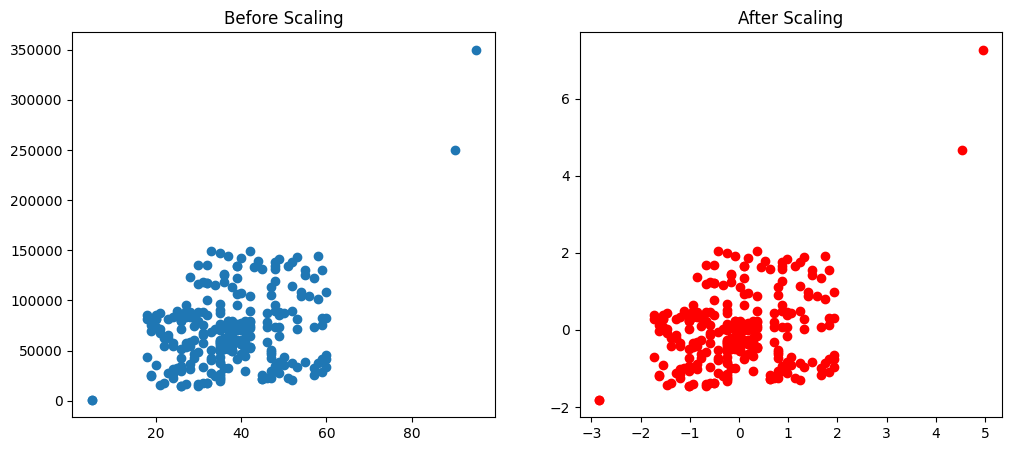

In [49]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

ax2.scatter(x_train_scale[:, 0], x_train_scale[:, 1], color='red')
ax2.set_title("After Scaling")

plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

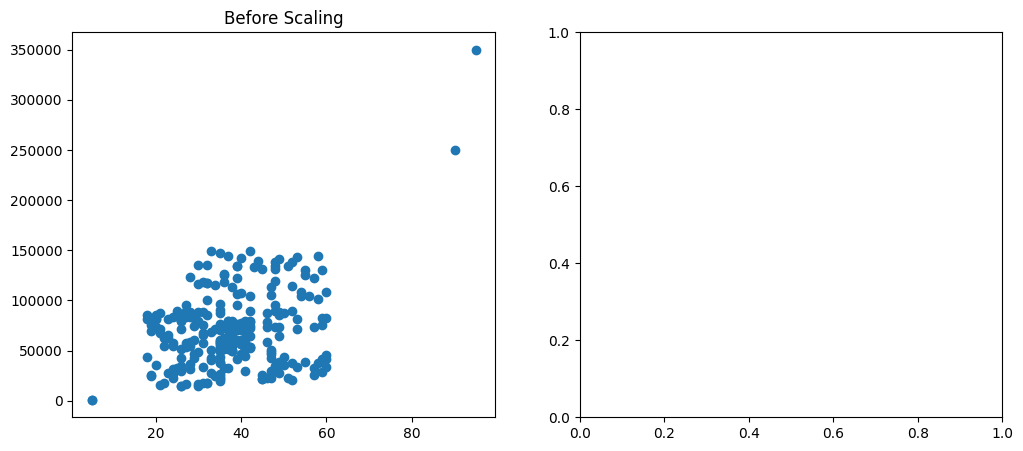

In [47]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scale['Age'], x_train_scale['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

_____________________________

**Apply Standard Scaler When Use these Modols!**

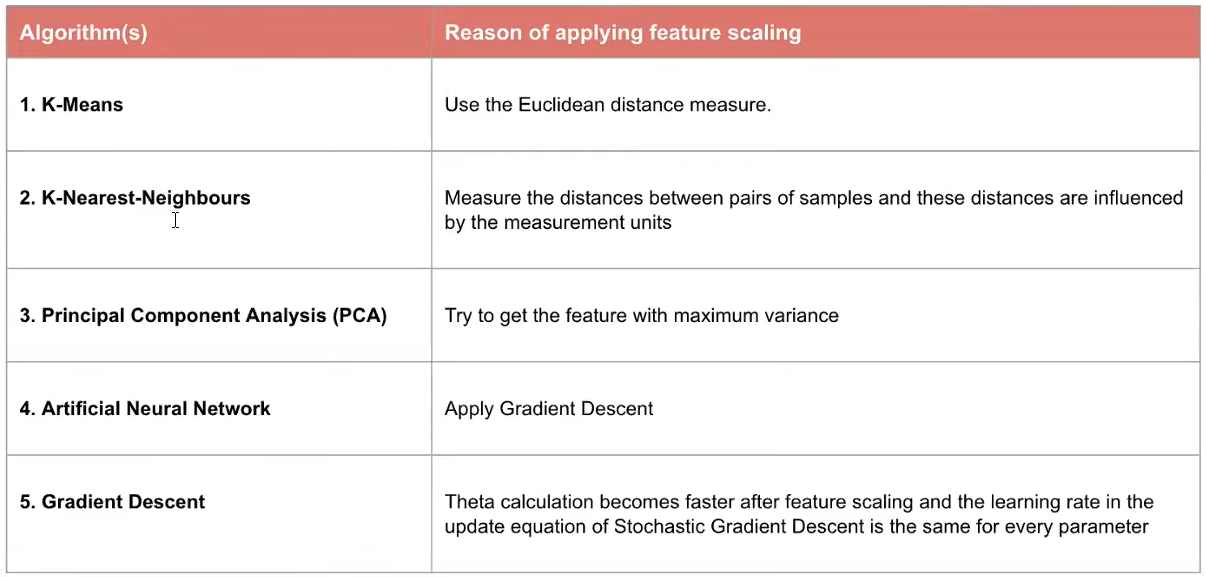